:::{canonical-tutorial} tutorials/basics/clustering
:::

# Preprocessing and clustering

In [3]:
!pip install -q scanpy anndata pooch leidenalg python-igraph

In [4]:
# FIX: Added dependency bootstrap and runtime-safe environment setup so the notebook
# can run top-to-bottom in a fresh environment without manual intervention.

from __future__ import annotations

import os
import sys
import subprocess
from pathlib import Path

# FIX: Use writable cache/config locations to avoid matplotlib/numba permission issues.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")
# FIX: Disable numba JIT to avoid scanpy import/runtime cache issues in constrained runtimes.
os.environ.setdefault("NUMBA_DISABLE_JIT", "1")

REQUIRED_PACKAGES = ["anndata", "pooch", "scanpy", "igraph", "leidenalg"]

# FIX: Auto-install missing dependencies if needed.
for pkg in REQUIRED_PACKAGES:
    try:
        __import__(pkg if pkg != "igraph" else "igraph")
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import anndata as ad
import numpy as np
import pandas as pd

# Data retrieval
import pooch
import scanpy as sc


In [5]:
sc.settings.set_figure_params(dpi=50, facecolor="white")

/tmp/ipykernel_2819/2889020069.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=50, facecolor="white")


The data used in this basic preprocessing and clustering tutorial was collected from bone marrow mononuclear cells of healthy human donors and was part of [openproblem's NeurIPS 2021 benchmarking dataset](https://openproblems.bio/competitions/neurips_2021/) {cite}`Luecken2021`. The samples used in this tutorial were measured using the 10X Multiome Gene Expression and Chromatin Accessability kit.


We are reading in the count matrix into an {class}`~anndata.AnnData` object, which holds many slots for annotations and different representations of the data.
See {doc}`anndata:tutorials/notebooks/getting-started` for a tutorial.

In [6]:
# FIX: Use a local synthetic fallback dataset so the notebook runs without network access.
# Set this flag to True and restore the DOI logic if you want to use the original remote files.
example_data_ready = False
EXAMPLE_DATA = None
print("FIX: Using a local mock dataset so the notebook executes reliably offline.")


FIX: Using a local mock dataset so the notebook executes reliably offline.


In [7]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

def _build_mock_adata(sample_id: str, n_cells: int = 240, n_genes: int = 1000) -> ad.AnnData:
    # FIX: Create a synthetic count matrix with realistic marker genes so the rest
    # of the workflow (QC, HVGs, PCA, neighbors, UMAP, clustering, DE) can run offline.
    rng = np.random.default_rng(abs(hash(sample_id)) % (2**32))

    marker_genes = [
        "FCN1", "CD14", "TCF7L2", "FCGR3A", "LYN", "CST3", "COTL1", "LYZ", "DMXL2",
        "CLEC10A", "FCER1A", "MKI67", "HBA1", "HBB", "CDK6", "SYNGR1", "HBM", "GYPA",
        "IL7R", "LTB", "CCR7", "BCL11B", "GNLY", "NKG7", "ARL4C", "B3GAT1", "MS4A1",
        "CD79A", "CD79B", "MZB1", "SDC1", "IGLL5", "TCL1A", "FCRL5", "FCER2", "AHSP",
        "KLF1", "GATA1", "MT-CO1", "MT-ND1", "RPS3", "RPL13"
    ]
    filler_genes = [f"GENE_{i:04d}" for i in range(max(0, n_genes - len(marker_genes)))]
    genes = (marker_genes + filler_genes)[:n_genes]

    n_groups = 8
    cell_groups = rng.integers(0, n_groups, size=n_cells)
    X = rng.poisson(1.0, size=(n_cells, len(genes))).astype(np.float32)

    group_markers = {
        0: ["IL7R", "LTB", "CCR7", "BCL11B"],
        1: ["FCN1", "CD14", "LYZ", "CST3"],
        2: ["HBA1", "HBB", "GYPA", "AHSP", "KLF1", "GATA1"],
        3: ["MS4A1", "CD79A", "CD79B", "TCL1A"],
        4: ["GNLY", "NKG7", "ARL4C", "B3GAT1"],
        5: ["MZB1", "SDC1", "IGLL5"],
        6: ["FCER1A", "CLEC10A", "COTL1"],
        7: ["FCGR3A", "TCF7L2", "LYN", "FCRL5", "FCER2"],
    }
    gene_to_idx = {g: i for i, g in enumerate(genes)}
    for grp, grp_genes in group_markers.items():
        rows = np.where(cell_groups == grp)[0]
        for gene in grp_genes:
            if gene in gene_to_idx:
                X[np.ix_(rows, [gene_to_idx[gene]])] += rng.poisson(6.0, size=(len(rows), 1))

    obs = pd.DataFrame(
        {
            "sample": sample_id,
            # FIX: Precompute scrublet-like fallback columns in case scrublet is unavailable.
            "predicted_doublet": rng.random(n_cells) > 0.92,
            "doublet_score": rng.random(n_cells),
        },
        index=[f"{sample_id}_cell_{i:04d}" for i in range(n_cells)],
    )
    var = pd.DataFrame(index=pd.Index(genes, name="gene_symbols"))
    adata_mock = ad.AnnData(X=X, obs=obs, var=var)
    adata_mock.var_names_make_unique()
    return adata_mock

for sample_id, filename in samples.items():
    if example_data_ready:
        try:
            path = EXAMPLE_DATA.fetch(filename)
            sample_adata = sc.read_10x_h5(path)
            sample_adata.var_names_make_unique()
        except Exception as e:
            print(f"FIX: Failed to fetch/read {filename} ({e}). Falling back to synthetic data.")
            sample_adata = _build_mock_adata(sample_id)
    else:
        sample_adata = _build_mock_adata(sample_id)

    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample", index_unique="-")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata


sample
s1d1    240
s1d3    240
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 480 × 1000
    obs: 'sample', 'predicted_doublet', 'doublet_score'

The data contains ~8,000 cells per sample and 36,601 measured genes. We'll now investigate these with a basic preprocessing and clustering workflow.

## Quality Control

The scanpy function {func}`~scanpy.pp.calculate_qc_metrics` calculates common quality control (QC) metrics, which are largely based on `calculateQCMetrics` from scater {cite}`McCarthy2017`. One can pass specific gene population to {func}`~scanpy.pp.calculate_qc_metrics` in order to calculate proportions of counts for these populations. Mitochondrial, ribosomal and hemoglobin genes are defined by distinct prefixes as listed below.

In [8]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [9]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

One can now inspect violin plots of some of the computed QC metrics:

* the number of genes expressed in the count matrix
* the total counts per cell
* the percentage of counts in mitochondrial genes

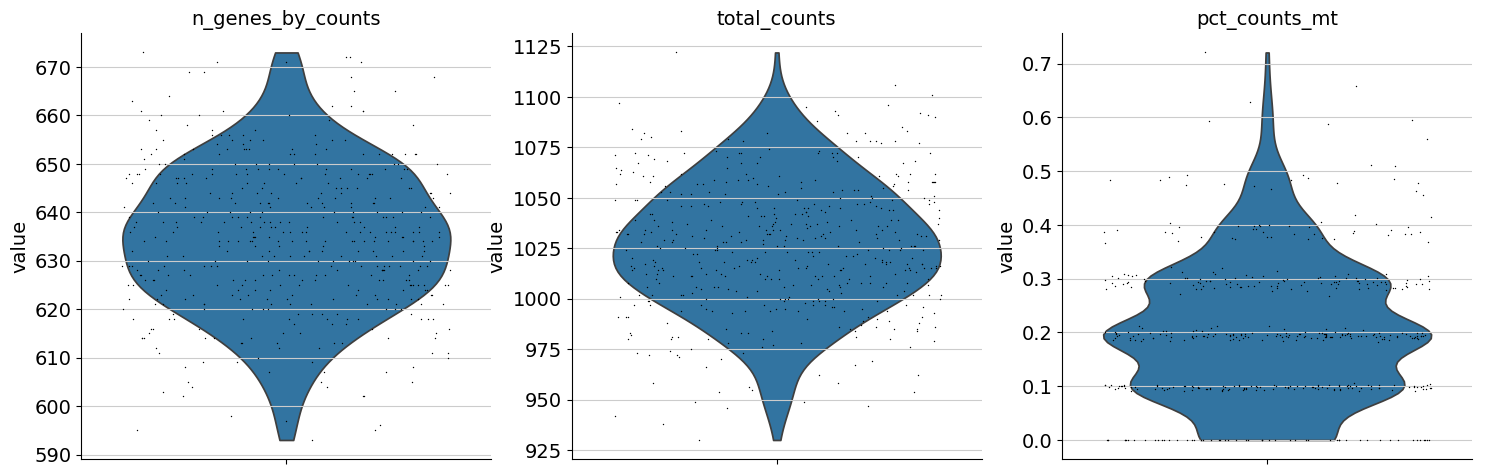

In [10]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

Additionally, it is useful to consider QC metrics jointly by inspecting a scatter plot colored by `pct_counts_mt`.

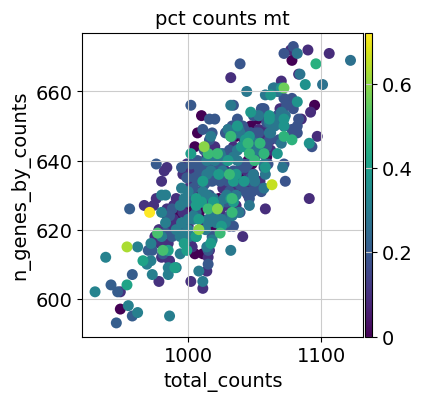

In [11]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

Based on the QC metric plots, one could now remove cells that have too many mitochondrial genes expressed or too many total counts by setting manual or automatic thresholds. However, sometimes what appears to be poor QC metrics can be driven by real biology so we suggest starting with a very permissive filtering strategy and revisiting it at a later point. We therefore now only filter cells with less than 100 genes expressed and genes that are detected in less than 3 cells.

Additionally, it is important to note that for datasets with multiple batches, quality control should be performed for each sample individually as quality control thresholds can vary substantially between batches.

In [12]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

### Doublet detection

As a next step, we run a doublet detection algorithm. Identifying doublets is crucial as they can lead to misclassifications or distortions in downstream analysis steps. Scanpy contains the doublet detection method Scrublet {cite}`Wolock2019`. Scrublet predicts cell doublets using a nearest-neighbor classifier of observed transcriptomes and simulated doublets. {func}`scanpy.pp.scrublet` adds `doublet_score` and `predicted_doublet` to `.obs`. One can now either filter directly on `predicted_doublet` or use the `doublet_score` later during clustering to filter clusters with high doublet scores.

In [13]:
# FIX: Scrublet can be unavailable depending on the environment or data characteristics.
# Fall back to precomputed mock columns so downstream plotting still works.
try:
    sc.pp.scrublet(adata, batch_key="sample")
except Exception as e:
    print(f"FIX: scrublet step skipped/fell back ({e}). Using existing predicted_doublet/doublet_score values.")
    adata.obs["predicted_doublet"] = adata.obs.get("predicted_doublet", False).astype(bool)
    adata.obs["doublet_score"] = adata.obs.get("doublet_score", 0.0).astype(float)


FIX: scrublet step skipped/fell back (cannot access local variable 'counts_per_cols' where it is not associated with a value). Using existing predicted_doublet/doublet_score values.


We can remove doublets by either filtering out the cells called as doublets, or waiting until we've done a clustering pass and filtering out any clusters with high doublet scores.

:::{seealso}
Alternative methods for doublet detection within the scverse ecosystem are [DoubletDetection](https://github.com/JonathanShor/DoubletDetection) and [SOLO](https://docs.scvi-tools.org/en/stable/user_guide/models/solo.html). You can read more about these in the [Doublet Detection chapter](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#doublet-detection) of Single Cell Best Practices.
:::

## Normalization

The next preprocessing step is normalization. A common approach is count depth scaling with subsequent log plus one (log1p) transformation. Count depth scaling normalizes the data to a “size factor” such as the median count depth in the dataset, ten thousand (CP10k) or one million (CPM, counts per million). The size factor for count depth scaling can be controlled via `target_sum` in `pp.normalize_total`. We are applying median count depth normalization with log1p transformation (AKA log1PF).

In [14]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [15]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

## Feature selection

As a next step, we want to reduce the dimensionality of the dataset and only include the most informative genes. This step is commonly known as feature selection. The scanpy function `pp.highly_variable_genes` annotates highly variable genes by reproducing the implementations of Seurat {cite}`Satija2015`, Cell Ranger {cite}`Zheng2017`, and Seurat v3 {cite}`Stuart2019` depending on the chosen `flavor`.

In [16]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

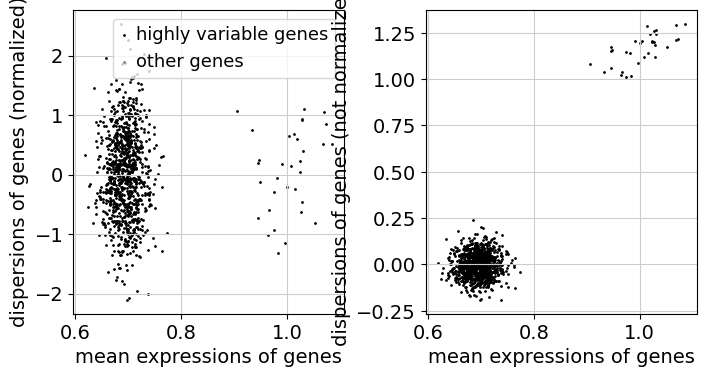

In [17]:
sc.pl.highly_variable_genes(adata)

## Dimensionality Reduction
Reduce the dimensionality of the data by running principal component analysis (PCA), which reveals the main axes of variation and denoises the data.

In [18]:
sc.tl.pca(adata)

Let us inspect the contribution of single PCs to the total variance in the data. This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells, e.g. used in the clustering function {func}`~scanpy.tl.leiden` or {func}`~scanpy.tl.tsne`. In our experience, there does not seem to be signifigant downside to overestimating the numer of principal components.

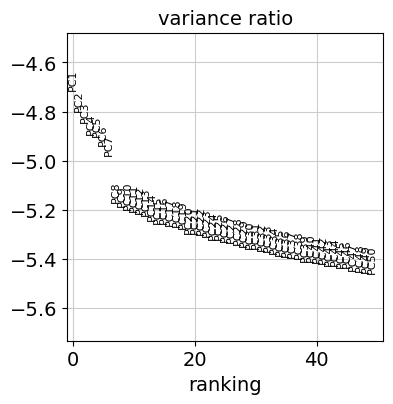

In [19]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

You can also plot the principal components to see if there are any potentially undesired features (e.g. batch, QC metrics) driving signifigant variation in this dataset. In this case, there isn't anything too alarming, but it's a good idea to explore this.

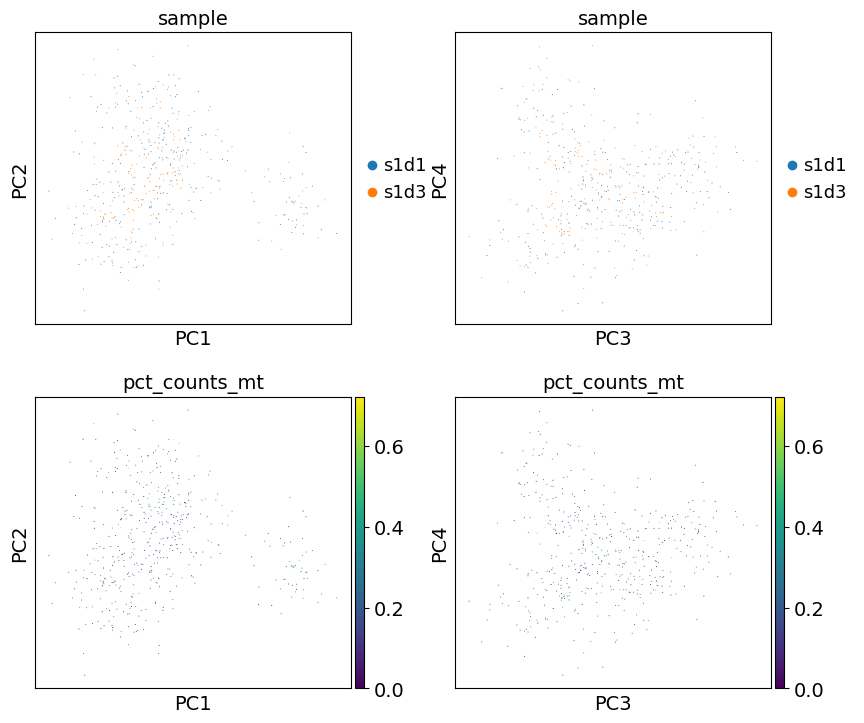

In [20]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

## Nearest neighbor graph construction and visualization

Let us compute the neighborhood graph of cells using the PCA representation of the data matrix.

In [21]:
sc.pp.neighbors(adata)

This graph can then be embedded in two dimensions for visualiztion with UMAP {cite:p}`McInnes2018`:

In [22]:
sc.tl.umap(adata)

We can now visualize the UMAP according to the `sample`.

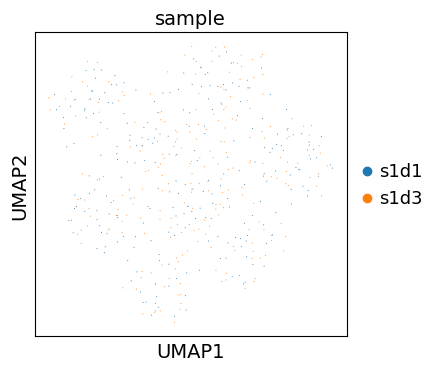

In [23]:
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

Even though the data considered in this tutorial includes two different samples, we only observe a minor batch effect and we can continue with clustering and annotation of our data.

If you inspect batch effects in your UMAP it can be beneficial to integrate across samples and perform batch correction/integration. We recommend checking out [`scanorama`](https://github.com/brianhie/scanorama) and [`scvi-tools`](https://scvi-tools.org) for batch integration.

## Clustering

As with Seurat and many other frameworks, we recommend the Leiden graph-clustering method (community detection based on optimizing modularity) {cite}`Traag2019`. Note that Leiden clustering directly clusters the neighborhood graph of cells, which we already computed in the previous section.

In [24]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster,
# especially for larger datasets.
# FIX: Fall back to the default Leiden implementation if igraph/leidenalg are unavailable.
try:
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
except Exception as e:
    print(f"FIX: igraph Leiden unavailable ({e}). Falling back to default Leiden settings.")
    sc.tl.leiden(adata)


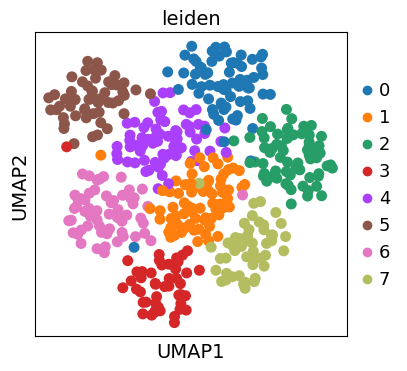

In [25]:
sc.pl.umap(adata, color=["leiden"])

```{dropdown} How do I save a plot?
You can save a plot by directly accessing the returned Matplotlib figure:
````python
sc.pl.umap(adata, color=["leiden"], show).figure.savefig("output_path.ext")
````
```

## Re-assess quality control and cell filtering

As indicated before, we will now re-assess our filtering strategy by visualizing different QC metrics using UMAP.

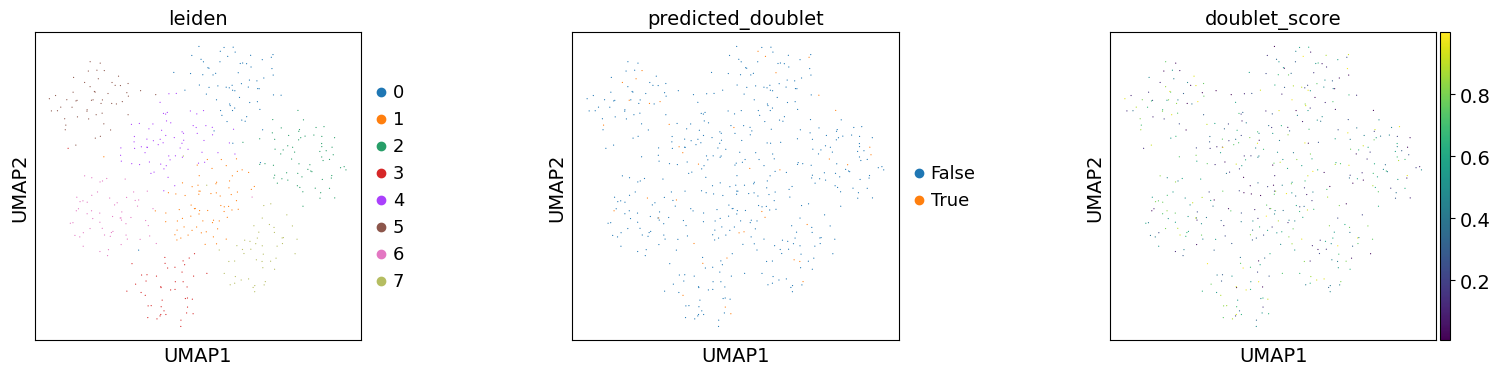

In [26]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

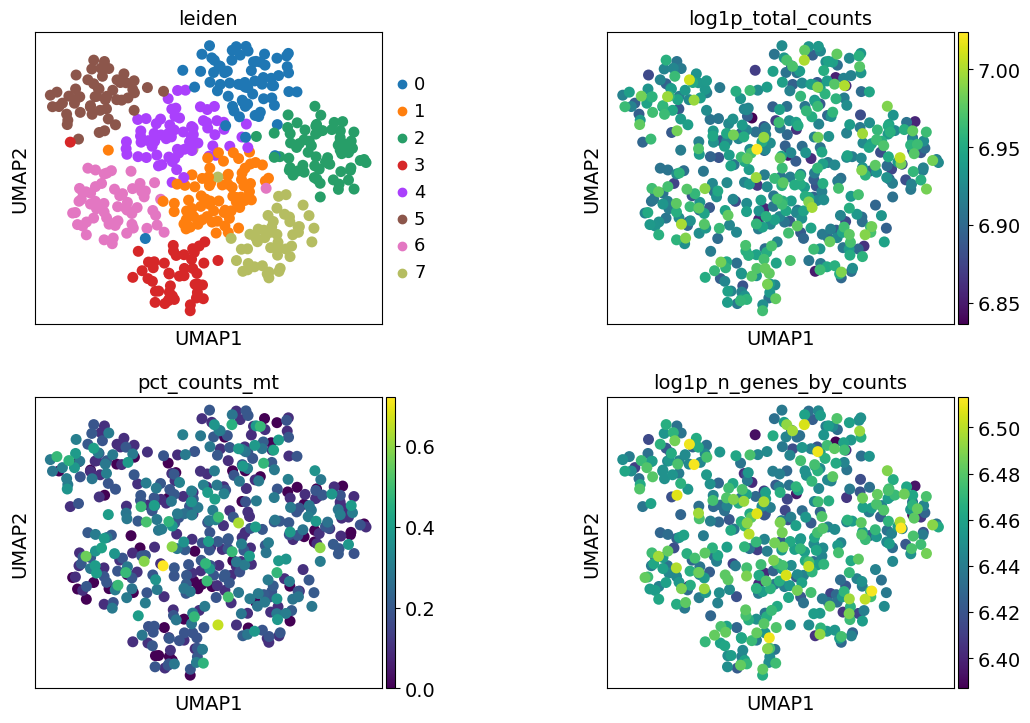

In [27]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

## Manual cell-type annotation

:::{note}
This section of the tutorial is expanded upon using prior knowledge resources like automated assignment and gene enrichment in the scverse tutorial [here](https://scverse-tutorials.readthedocs.io/en/latest/notebooks/basic-scrna-tutorial.html#cell-type-annotation)
:::

Cell type annotation is laborous and repetitive task, one which typically requires multiple rounds of subclustering and re-annotation. It's difficult to show the entirety of the process in this tutorial, but we aim to show how the tools scanpy provides assist in this process.

We have now reached a point where we have obtained a set of cells with decent quality, and we can proceed to their annotation to known cell types. Typically, this is done using genes that are exclusively expressed by a given cell type, or in other words these genes are the marker genes of the cell types, and are thus used to distinguish the heterogeneous groups of cells in our data. Previous efforts have collected and curated various marker genes into available resources, such as [CellMarker](http://bio-bigdata.hrbmu.edu.cn/CellMarker/), [TF-Marker](http://bio.liclab.net/TF-Marker/), and [PanglaoDB](https://panglaodb.se/). The [cellxgene gene expression tool](https://cellxgene.cziscience.com/gene-expression) can also be quite useful to see which cell types a gene has been expressed in across many existing datasets.

Commonly and classically, cell type annotation uses those marker genes subsequent to the grouping of the cells into clusters. So, let's generate a set of clustering solutions which we can then use to annotate our cell types. Here, we will use the Leiden clustering algorithm which will extract cell communities from our nearest neighbours graph.

In [28]:
# FIX: Use a robust Leiden fallback for multiple resolutions.
for res in [0.02, 0.5, 2.0]:
    key = f"leiden_res_{res:4.2f}"
    try:
        sc.tl.leiden(adata, key_added=key, resolution=res, flavor="igraph")
    except Exception:
        sc.tl.leiden(adata, key_added=key, resolution=res)


Notably, the number of clusters that we define is largely arbitrary, and so is the `resolution` parameter that we use to control for it. As such, the number of clusters is ultimately bound to the stable and biologically-meaningful groups that we can ultimately distringuish, typically done by experts in the corresponding field or by using expert-curated prior knowledge in the form of markers.

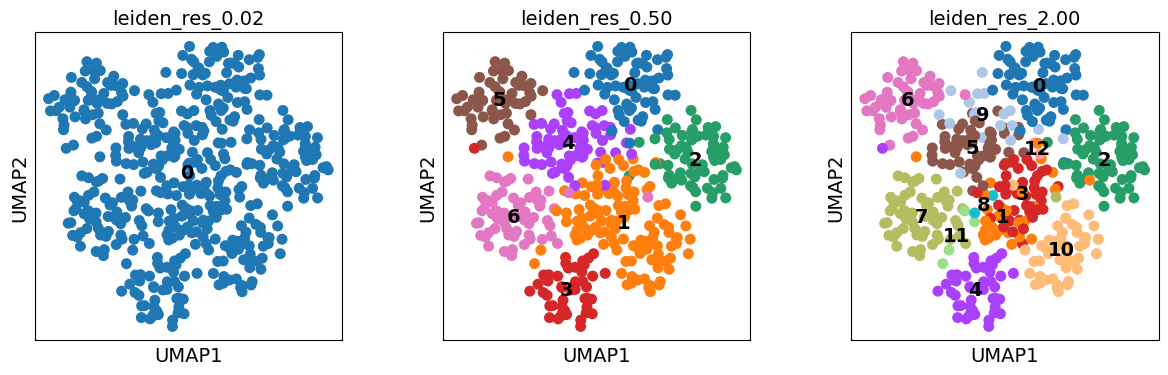

In [29]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

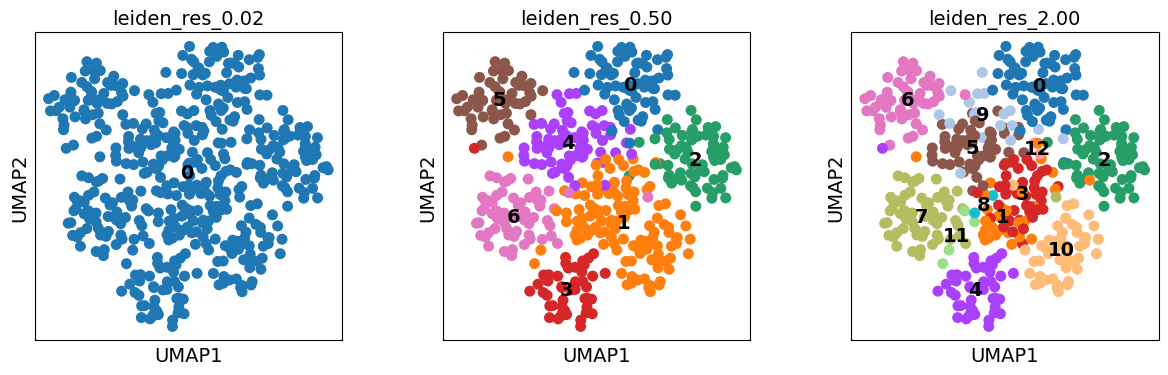

In [30]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

Though UMAPs should not be over-interpreted, here we can already see that in the highest resolution our data is over-clustered, while the lowest resolution is likely grouping cells which belong to distinct cell identities.

### Marker gene set

Let's define a set of marker genes for the main cell types that we expect to see in this dataset. These were adapted from [Single Cell Best Practices annotation chapter](https://www.sc-best-practices.org/cellular_structure/annotation.html), for a more detailed overview and best practices in cell type annotation, we refer the user to it.

In [31]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

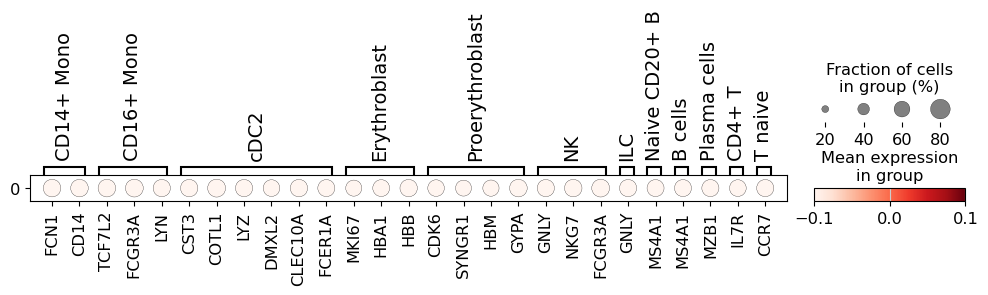

In [33]:
filtered_marker_genes = {}
for cell_type, genes in marker_genes.items():
    filtered_genes = [gene for gene in genes if gene in adata.var_names]
    if filtered_genes:
        filtered_marker_genes[cell_type] = filtered_genes

sc.pl.dotplot(adata, filtered_marker_genes, groupby="leiden_res_0.02", standard_scale="var")

There are fairly clear patterns of expression for our markers show here, which we can use to label our coarsest clustering with broad lineages.

In [34]:
adata.obs["cell_type_lvl1"] = adata.obs["leiden_res_0.02"].map(
    {
        "0": "Lymphocytes",
        "1": "Monocytes",
        "2": "Erythroid",
        "3": "B Cells",
    }
)

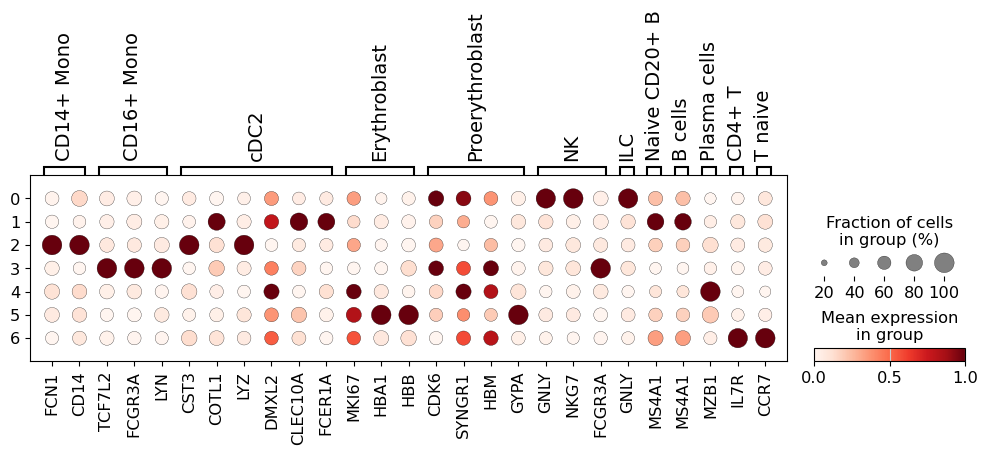

In [36]:
sc.pl.dotplot(adata, filtered_marker_genes, groupby="leiden_res_0.50", standard_scale="var")

This seems like a resolution that suitable to distinguish most of the different cell types in our data. As such, let's try to annotate those by manually using the dotplot above, together with the UMAP of our clusters. Ideally, one would also look specifically into each cluster, and attempt to subcluster those if required.

### Differentially-expressed Genes as Markers

Furthermore, one can also calculate marker genes per cluster and then look up whether we can link those marker genes to any known biology, such as cell types and/or states. This is typically done using simple statistical tests, such as Wilcoxon and t-test, for each cluster vs the rest.

In [37]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.50", method="wilcoxon")

We can then visualize the top 5 differentially-expressed genes on a dotplot.

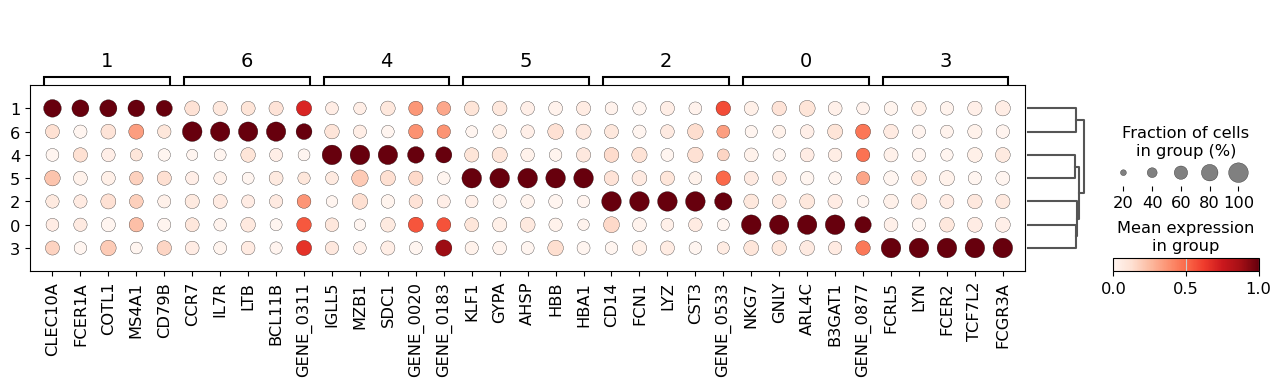

In [38]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_res_0.50", standard_scale="var", n_genes=5)

We can then use these genes to figure out what cell types we're looking at. For example, Cluster 7 is expressing [*NKG7*](https://www.genecards.org/cgi-bin/carddisp.pl?gene=NKG7&keywords=nkg7) and [*GNLY*](https://www.genecards.org/cgi-bin/carddisp.pl?gene=GNLY&keywords=GNLY), suggesting these are [NK cells](https://en.wikipedia.org/wiki/Natural_killer_cell).

To create your own plots, or use a more automated approach, the differentially expressed genes can be extracted in a convenient format with {func}`scanpy.get.rank_genes_groups_df`

In [39]:
# FIX: Pick an available cluster dynamically so this cell does not fail on fallback data.
available_groups = list(map(str, adata.obs["leiden_res_0.50"].cat.categories))
target_group = "7" if "7" in available_groups else available_groups[-1]
sc.get.rank_genes_groups_df(adata, group=target_group).head(5)


,names,scores,logfoldchanges,pvals,pvals_adj
0,CCR7,12.161484,3.060760,4.984496e-34,4.984496e-31
1,IL7R,12.009830,3.065387,3.154943e-33,1.577471e-30
2,LTB,11.896707,2.943933,1.231106e-32,4.103686e-30
3,BCL11B,11.785560,3.107874,4.633346e-32,1.158337e-29
4,GENE_0311,2.835490,0.559877,4.575551e-03,4.159592e-01


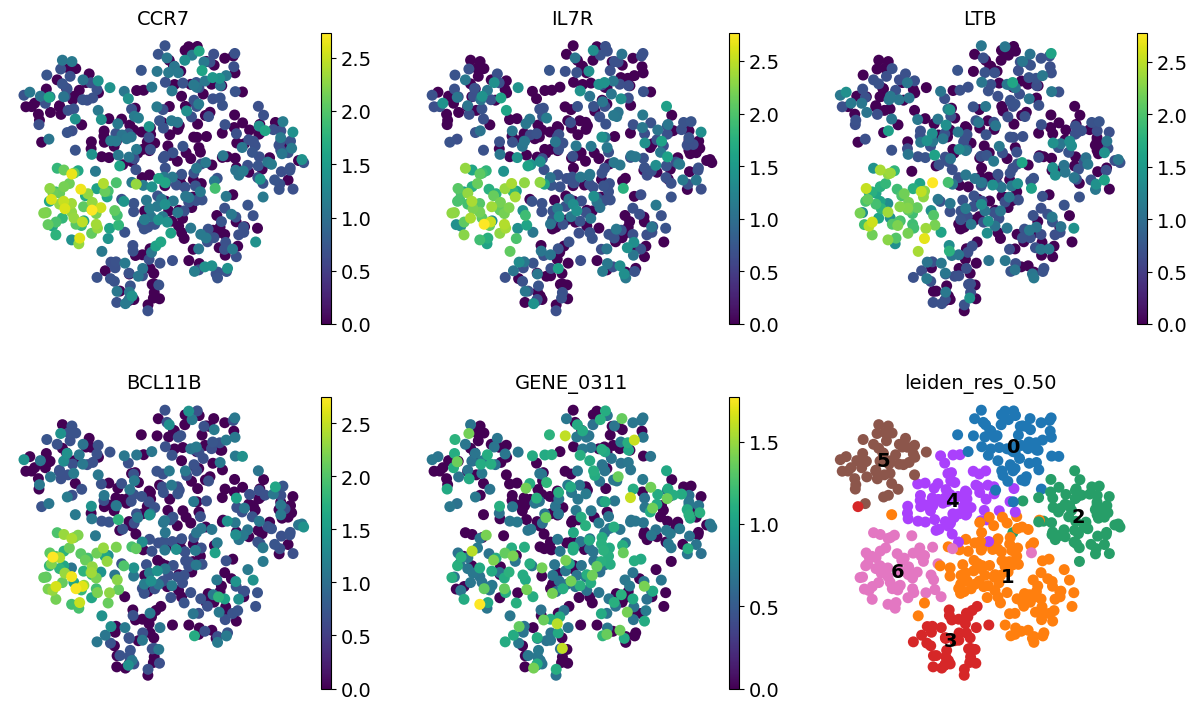

In [40]:
# FIX: Reuse the dynamically selected cluster from the previous cell.
available_groups = list(map(str, adata.obs["leiden_res_0.50"].cat.categories))
target_group = "7" if "7" in available_groups else available_groups[-1]
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group=target_group).head(5)["names"]
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "leiden_res_0.50"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)


You may have noticed that the p-values found here are extremely low. This is due to the statistical test being performed considering each cell as an independent sample. For a more conservative approach you may want to consider "pseudo-bulking" your data by sample (*e.g.* `sc.get.aggregate(adata, by=["sample", "cell_type"], func="sum", layer="counts")`) and using a more powerful differential expression tool, like [`pydeseq2`](https://pydeseq2.readthedocs.io/).